# ĐỀ TÀI #1: CUSTOMER LIFECYCLE & COHORT RETENTION
## Acquisition Channel Quality (Paid Search vs Social Media)

### Framework: D-Di-P-Pr (Descriptive-Diagnostic-Predictive-Prescriptive)

**Mục tiêu:**
- Đo retention theo cohort và acquisition_channel
- Kiểm chứng hypothesis: paid_search giữ chân khách tốt hơn social_media
- Định lượng cơ hội tăng trưởng từ re-engagement
- Đưa ra kiến nghị hành động cụ thể có định lượng

**Insight chính:** "Acquisition tốt không chỉ mua lần 1, mà phải mua lần 2."

In [ ]:
%pip install numpy pandas matplotlib seaborn scikit-learn

In [1]:
# ============================================================================
# CELL 1: CONFIG & IMPORTS
# ============================================================================
import os
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

cwd = Path.cwd().resolve()
candidate_data_dirs = [
    cwd / 'data' / 'datathon-2026-round-1',
    cwd.parent / 'data' / 'datathon-2026-round-1',
    cwd.parent.parent / 'data' / 'datathon-2026-round-1',
    cwd.parent.parent.parent / 'data' / 'datathon-2026-round-1',
]
DATA_DIR = next((p for p in candidate_data_dirs if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        'Could not find data/datathon-2026-round-1 from current working directory. '
        f'Current cwd: {cwd}'
    )

DATA_PATH = str(DATA_DIR) + os.sep
OUTPUT_DIR = cwd / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH = str(OUTPUT_DIR) + os.sep

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print(f'✓ Pandas: {pd.__version__}')
print(f'✓ NumPy: {np.__version__}')
print(f'✓ Seed: {SEED}')
print(f'✓ CWD: {cwd}')
print(f'✓ Data path: {DATA_PATH}')
print(f'✓ Output path: {OUTPUT_PATH}')

✓ Pandas: 3.0.2
✓ NumPy: 2.4.4
✓ Seed: 42
✓ CWD: D:\Datathon2026\TuNgayToiGapEm\phan_2_eda\outputs\idea_1
✓ Data path: D:\Datathon2026\TuNgayToiGapEm\data\datathon-2026-round-1\
✓ Output path: D:\Datathon2026\TuNgayToiGapEm\phan_2_eda\outputs\idea_1\outputs\


## CELL 2: Load Data

In [2]:
# ============================================================================
# CELL 2: LOAD DATA
# ============================================================================
print('='*70)
print('LOADING DATA')
print('='*70)

customers = pd.read_csv(f'{DATA_PATH}customers.csv')
orders = pd.read_csv(f'{DATA_PATH}orders.csv')

orders['order_date'] = pd.to_datetime(orders['order_date'])
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

orders = orders.sort_values('order_date').reset_index(drop=True)

print(f'\n✓ Customers shape: {customers.shape}')
print(f'✓ Orders shape: {orders.shape}')
print(f'✓ Orders date range: {orders["order_date"].min()} to {orders["order_date"].max()}')

print('\nCustomer key missing values:')
print(customers[['customer_id', 'acquisition_channel', 'age_group']].isna().mean().round(3))

print('\nTop acquisition channels:')
print(customers['acquisition_channel'].fillna('unknown').value_counts().head(10))

LOADING DATA

✓ Customers shape: (121930, 7)
✓ Orders shape: (646945, 8)
✓ Orders date range: 2012-07-04 00:00:00 to 2022-12-31 00:00:00

Customer key missing values:
customer_id            0.0
acquisition_channel    0.0
age_group              0.0
dtype: float64

Top acquisition channels:
acquisition_channel
organic_search    36450
social_media      24448
paid_search       24285
email_campaign    14674
referral          12270
direct             9803
Name: count, dtype: int64


## CELL 3: Build Customer Lifecycle Table

In [3]:
# ============================================================================
# CELL 3: CUSTOMER LIFECYCLE FEATURES
# ============================================================================
order_stats = orders.groupby('customer_id').agg(
    first_order=('order_date', 'min'),
    last_order=('order_date', 'max'),
    total_orders=('order_id', 'count')
).reset_index()

orders_gap = orders.sort_values(['customer_id', 'order_date']).copy()
orders_gap['prev_order_date'] = orders_gap.groupby('customer_id')['order_date'].shift(1)
orders_gap['order_gap_days'] = (orders_gap['order_date'] - orders_gap['prev_order_date']).dt.days
avg_gap = orders_gap.groupby('customer_id')['order_gap_days'].mean().reset_index(name='avg_gap_days')

as_of_date = orders['order_date'].max()

lifecycle = customers[['customer_id', 'acquisition_channel', 'age_group', 'gender']].merge(
    order_stats, on='customer_id', how='left'
)
lifecycle = lifecycle.merge(avg_gap, on='customer_id', how='left')

lifecycle['total_orders'] = lifecycle['total_orders'].fillna(0)
lifecycle['is_buyer'] = (lifecycle['total_orders'] > 0).astype(int)
lifecycle['is_repeat'] = (lifecycle['total_orders'] > 1).astype(int)
lifecycle['days_active'] = (lifecycle['last_order'] - lifecycle['first_order']).dt.days.fillna(0)
lifecycle['recency_days'] = (as_of_date - lifecycle['last_order']).dt.days.fillna((as_of_date - customers['signup_date']).dt.days.median())

orders_with_first = orders.merge(order_stats[['customer_id', 'first_order']], on='customer_id', how='left')
orders_with_first['days_from_first'] = (orders_with_first['order_date'] - orders_with_first['first_order']).dt.days

retention_30 = orders_with_first[orders_with_first['days_from_first'].between(1, 30)].groupby('customer_id').size()
retention_90 = orders_with_first[orders_with_first['days_from_first'].between(1, 90)].groupby('customer_id').size()
retention_180 = orders_with_first[orders_with_first['days_from_first'].between(1, 180)].groupby('customer_id').size()

lifecycle['retained_30d'] = lifecycle['customer_id'].isin(retention_30.index).astype(int)
lifecycle['retained_90d'] = lifecycle['customer_id'].isin(retention_90.index).astype(int)
lifecycle['retained_180d'] = lifecycle['customer_id'].isin(retention_180.index).astype(int)
lifecycle['acquisition_channel'] = lifecycle['acquisition_channel'].fillna('unknown')

print(f'✓ Lifecycle table shape: {lifecycle.shape}')
print(f'✓ Buyers: {lifecycle["is_buyer"].sum():,} / {len(lifecycle):,}')
print(f'✓ Repeat buyers: {lifecycle["is_repeat"].sum():,}')
print(f'✓ 90d retained customers: {lifecycle["retained_90d"].sum():,}')

✓ Lifecycle table shape: (121930, 15)
✓ Buyers: 90,246 / 121,930
✓ Repeat buyers: 67,888
✓ 90d retained customers: 15,887


## CELL 4: Build Cohort Matrix

In [4]:
# ============================================================================
# CELL 4: COHORT RETENTION TABLE
# ============================================================================
cohort_df = orders[['customer_id', 'order_date']].copy()
cohort_df['order_month'] = cohort_df['order_date'].dt.to_period('M')
cohort_start = cohort_df.groupby('customer_id')['order_month'].min().rename('cohort_month')
cohort_df = cohort_df.merge(cohort_start, on='customer_id', how='left')
cohort_df['cohort_index'] = (cohort_df['order_month'].dt.year - cohort_df['cohort_month'].dt.year) * 12 + (cohort_df['order_month'].dt.month - cohort_df['cohort_month'].dt.month)

cohort_counts = cohort_df.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index(name='customers')
cohort_size = cohort_counts[cohort_counts['cohort_index'] == 0][['cohort_month', 'customers']].rename(columns={'customers': 'cohort_size'})
cohort_counts = cohort_counts.merge(cohort_size, on='cohort_month', how='left')
cohort_counts['retention_rate'] = cohort_counts['customers'] / cohort_counts['cohort_size']

cohort_pivot = cohort_counts.pivot(index='cohort_month', columns='cohort_index', values='retention_rate').sort_index()
cohort_pivot = cohort_pivot.iloc[-18:, :13]

print(f'✓ Cohort matrix shape: {cohort_pivot.shape}')
print('\nCohort retention sample (latest 5 cohorts):')
print((cohort_pivot.tail(5) * 100).round(1))

✓ Cohort matrix shape: (18, 13)

Cohort retention sample (latest 5 cohorts):
cohort_index     0   1   2    3    4   5   6   7   8   9   10  11  12
cohort_month                                                         
2022-08       100.0 NaN NaN  0.8  0.8 NaN NaN NaN NaN NaN NaN NaN NaN
2022-09       100.0 NaN NaN  1.1  NaN NaN NaN NaN NaN NaN NaN NaN NaN
2022-10       100.0 NaN NaN  NaN  NaN NaN NaN NaN NaN NaN NaN NaN NaN
2022-11       100.0 NaN NaN  NaN  NaN NaN NaN NaN NaN NaN NaN NaN NaN
2022-12       100.0 NaN NaN  NaN  NaN NaN NaN NaN NaN NaN NaN NaN NaN


---

# TẦNG 1: DESCRIPTIVE — "What happened?"

Mô tả phân phối vòng đời khách hàng theo kênh acquisition và retention window.

In [5]:
# ============================================================================
# CELL 5: DESCRIPTIVE ANALYSIS
# ============================================================================
print('='*70)
print('TẦNG 1: DESCRIPTIVE — CUSTOMER LIFECYCLE OVERVIEW')
print('='*70)

buyers = lifecycle[lifecycle['is_buyer'] == 1].copy()

print('\n📊 Customer Overview:')
print(f'  Total customers: {len(lifecycle):,}')
print(f'  Buyers: {buyers.shape[0]:,} ({buyers.shape[0]/len(lifecycle)*100:.1f}%)')
print(f'  Repeat buyers: {buyers["is_repeat"].sum():,} ({buyers["is_repeat"].mean()*100:.1f}% of buyers)')
print(f'  Avg orders per buyer: {buyers["total_orders"].mean():.2f}')
print(f'  Median recency (days): {buyers["recency_days"].median():.0f}')

channel_summary = buyers.groupby('acquisition_channel').agg(
    buyers=('customer_id', 'nunique'),
    avg_orders=('total_orders', 'mean'),
    repeat_rate=('is_repeat', 'mean'),
    retention_30d=('retained_30d', 'mean'),
    retention_90d=('retained_90d', 'mean'),
    retention_180d=('retained_180d', 'mean')
).sort_values('buyers', ascending=False)

print('\n📈 Channel Summary (top 10 by buyers):')
print((channel_summary.head(10) * [1,1,100,100,100,100]).round(2))

print('\n💡 Initial insight:')
top_channel = channel_summary['retention_90d'].idxmax()
bottom_channel = channel_summary['retention_90d'].idxmin()
print(f'  Best 90d retention channel: {top_channel} ({channel_summary.loc[top_channel, "retention_90d"]*100:.1f}%)')
print(f'  Worst 90d retention channel: {bottom_channel} ({channel_summary.loc[bottom_channel, "retention_90d"]*100:.1f}%)')

TẦNG 1: DESCRIPTIVE — CUSTOMER LIFECYCLE OVERVIEW

📊 Customer Overview:
  Total customers: 121,930
  Buyers: 90,246 (74.0%)
  Repeat buyers: 67,888 (75.2% of buyers)
  Avg orders per buyer: 7.17
  Median recency (days): 991

📈 Channel Summary (top 10 by buyers):
                     buyers  avg_orders  repeat_rate  retention_30d  \
acquisition_channel                                                   
organic_search        26950        7.21        75.38           8.26   
social_media          18002        7.19        75.67           8.75   
paid_search           17999        7.16        75.02           8.09   
email_campaign        10886        7.14        74.77           8.12   
referral               9072        7.11        75.13           7.85   
direct                 7337        7.09        74.84           7.95   

                     retention_90d  retention_180d  
acquisition_channel                                 
organic_search               17.79           27.53  
social_me

## CELL 6: Visualization 1 - Cohort Retention Heatmap

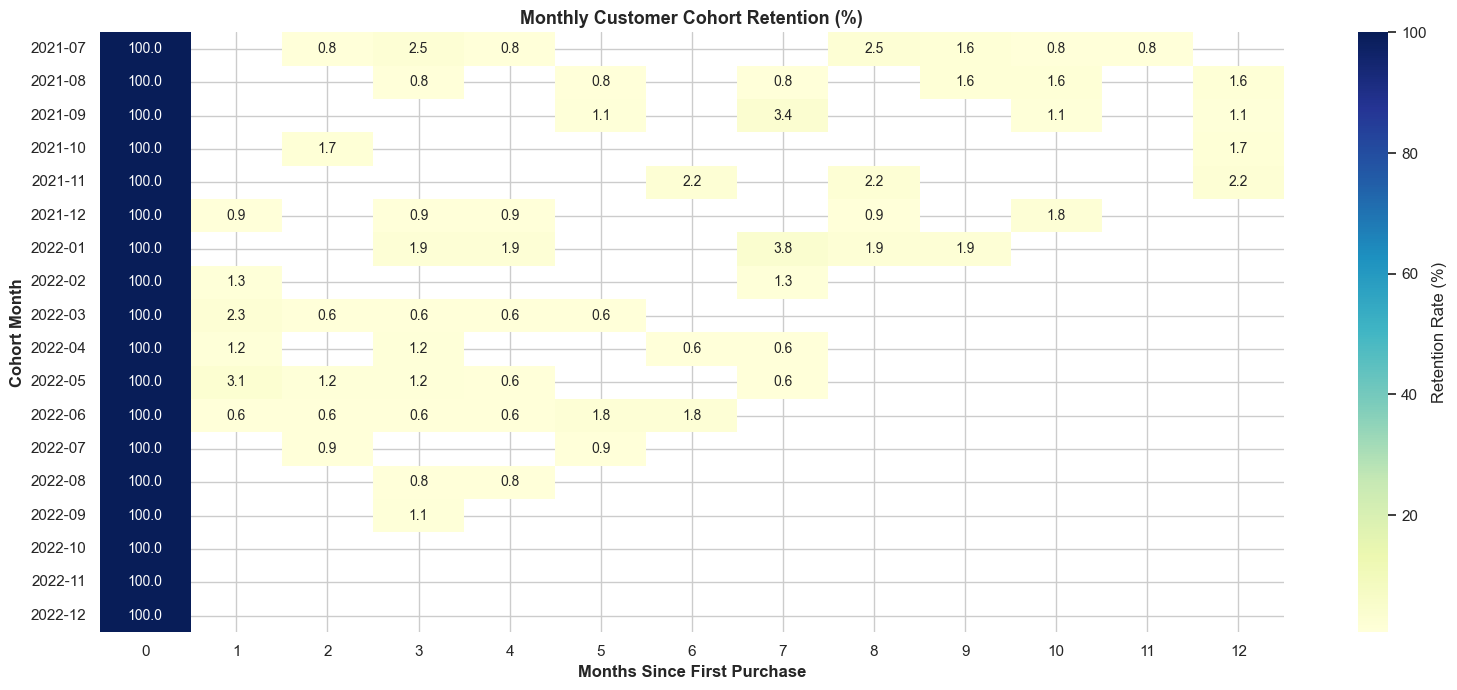

✓ Saved: 01_cohort_heatmap.png


In [6]:
# ============================================================================
# CELL 6: VISUALIZATION 1 - Cohort Heatmap
# ============================================================================
fig, ax = plt.subplots(figsize=(16, 7))

sns.heatmap(
    cohort_pivot * 100,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Retention Rate (%)'},
    ax=ax
)

ax.set_title('Monthly Customer Cohort Retention (%)', fontweight='bold', fontsize=13)
ax.set_xlabel('Months Since First Purchase', fontweight='bold')
ax.set_ylabel('Cohort Month', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}01_cohort_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved: 01_cohort_heatmap.png')

## CELL 7: Visualization 2 - 90-Day Retention by Acquisition Channel

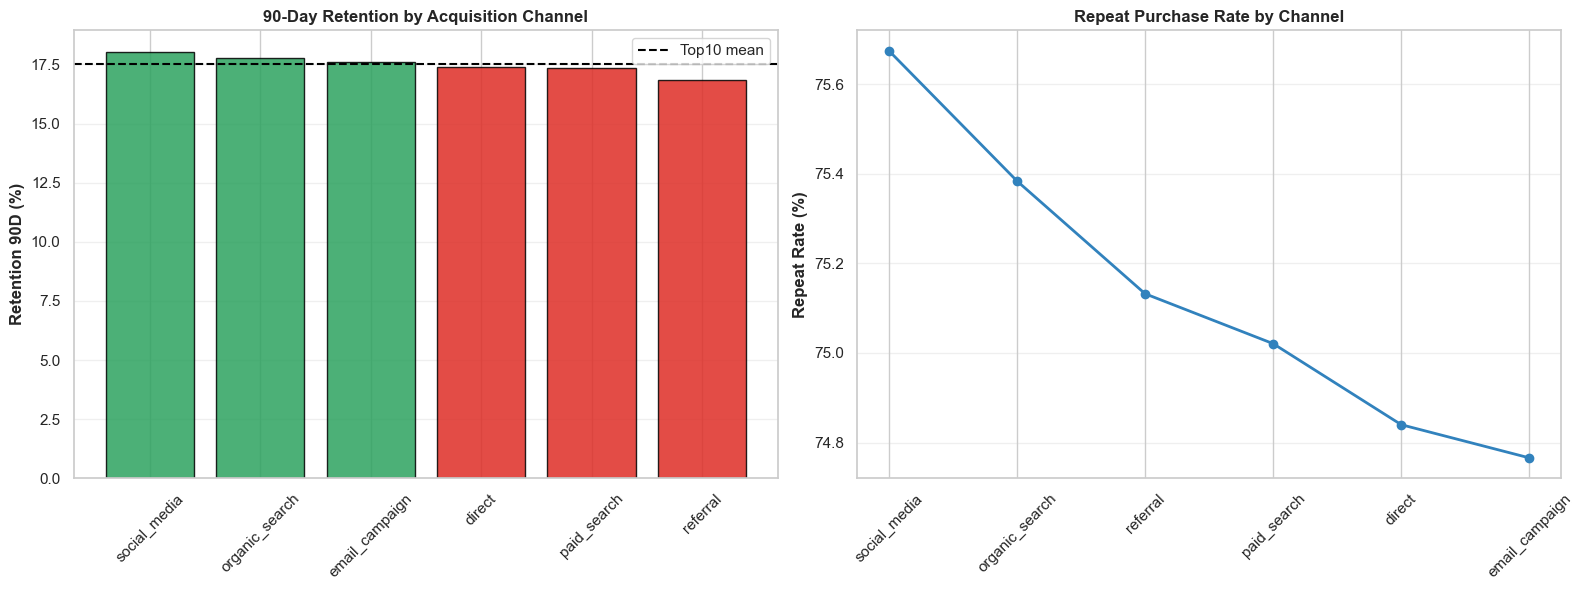

✓ Saved: 02_channel_retention.png


In [7]:
# ============================================================================
# CELL 7: VISUALIZATION 2 - Channel Retention
# ============================================================================
channel_retention = buyers.groupby('acquisition_channel')['retained_90d'].mean().sort_values(ascending=False)
channel_retention = channel_retention.head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#2ca25f' if x >= channel_retention.mean() else '#de2d26' for x in channel_retention.values]
ax1.bar(channel_retention.index, channel_retention.values * 100, color=colors, alpha=0.85, edgecolor='black')
ax1.axhline(channel_retention.mean() * 100, color='black', linestyle='--', linewidth=1.5, label='Top10 mean')
ax1.set_title('90-Day Retention by Acquisition Channel', fontweight='bold')
ax1.set_ylabel('Retention 90D (%)', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.legend()
ax1.grid(True, axis='y', alpha=0.3)

repeat_rate = buyers.groupby('acquisition_channel')['is_repeat'].mean().sort_values(ascending=False).head(10)
ax2.plot(repeat_rate.index, repeat_rate.values * 100, marker='o', linewidth=2, color='#3182bd')
ax2.set_title('Repeat Purchase Rate by Channel', fontweight='bold')
ax2.set_ylabel('Repeat Rate (%)', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}02_channel_retention.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved: 02_channel_retention.png')

---

# TẦNG 2-3: DIAGNOSTIC & PREDICTIVE

Phân tích nguyên nhân retention chênh lệch theo channel và dự báo xu hướng ngắn hạn.

In [8]:
# ============================================================================
# CELL 8: DIAGNOSTIC + SIMPLE PREDICTIVE
# ============================================================================
print('='*70)
print('TẦNG 2-3: DIAGNOSTIC & PREDICTIVE')
print('='*70)

channel_diag = buyers.groupby('acquisition_channel').agg(
    buyers=('customer_id', 'nunique'),
    avg_gap_days=('avg_gap_days', 'mean'),
    recency_days=('recency_days', 'mean'),
    retention_90d=('retained_90d', 'mean')
).sort_values('buyers', ascending=False)

main_channels = channel_diag.head(5).copy()
print('\n📊 Main channels diagnostic:')
print((main_channels.assign(retention_90d=main_channels['retention_90d']*100)).round(2))

# Predictive: trend retention across recent cohorts
cohort_ret = cohort_counts[cohort_counts['cohort_index'] == 3].copy()
cohort_ret = cohort_ret.sort_values('cohort_month').tail(18)
cohort_ret = cohort_ret.dropna(subset=['retention_rate'])

if len(cohort_ret) >= 6:
    X = np.arange(len(cohort_ret)).reshape(-1, 1)
    y = cohort_ret['retention_rate'].values
    lr = LinearRegression()
    lr.fit(X, y)
    next_3 = lr.predict(np.arange(len(cohort_ret), len(cohort_ret) + 3).reshape(-1, 1))
    next_3 = np.clip(next_3, 0, 1)
    forecast_retention_3m = float(next_3.mean())
else:
    forecast_retention_3m = float(cohort_ret['retention_rate'].mean()) if len(cohort_ret) > 0 else np.nan

print(f'\n🔮 Forecast (simple linear trend): expected 3-month retention index-3 = {forecast_retention_3m*100:.1f}%')

paid_key = [c for c in channel_diag.index if 'paid' in str(c).lower()]
social_key = [c for c in channel_diag.index if 'social' in str(c).lower()]
paid_90 = channel_diag.loc[paid_key[0], 'retention_90d'] if len(paid_key) > 0 else np.nan
social_90 = channel_diag.loc[social_key[0], 'retention_90d'] if len(social_key) > 0 else np.nan

if pd.notna(paid_90) and pd.notna(social_90) and social_90 > 0:
    ratio_paid_social = paid_90 / social_90
    print(f'💡 Hypothesis check: paid vs social retention ratio = {ratio_paid_social:.2f}x')
else:
    ratio_paid_social = np.nan
    print('💡 Hypothesis check: paid/social channels not both available in data labels.')

TẦNG 2-3: DIAGNOSTIC & PREDICTIVE

📊 Main channels diagnostic:
                     buyers  avg_gap_days  recency_days  retention_90d
acquisition_channel                                                   
organic_search        26950        559.30       1253.60          17.79
social_media          18002        556.82       1252.00          18.04
paid_search           17999        563.95       1252.24          17.37
email_campaign        10886        560.44       1263.68          17.59
referral               9072        566.28       1248.98          16.84

🔮 Forecast (simple linear trend): expected 3-month retention index-3 = 0.9%
💡 Hypothesis check: paid vs social retention ratio = 0.96x


## CELL 9: Visualization 3 - Retention Curve by Channel

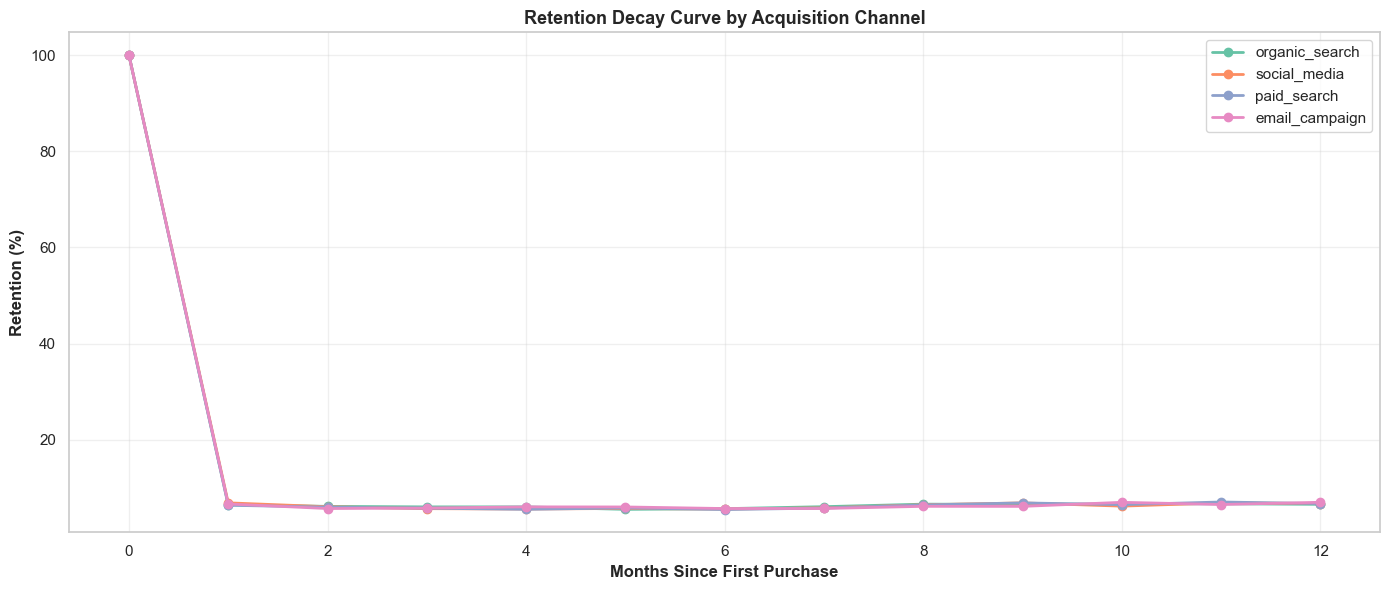

✓ Saved: 03_retention_curve.png


In [9]:
# ============================================================================
# CELL 9: VISUALIZATION 3 - Retention Curves
# ============================================================================
orders_ch = orders.merge(customers[['customer_id', 'acquisition_channel']], on='customer_id', how='left')
orders_ch['acquisition_channel'] = orders_ch['acquisition_channel'].fillna('unknown')
orders_ch['order_month'] = orders_ch['order_date'].dt.to_period('M')
first_month_ch = orders_ch.groupby('customer_id')['order_month'].min().rename('cohort_month')
orders_ch = orders_ch.merge(first_month_ch, on='customer_id', how='left')
orders_ch['cohort_index'] = (orders_ch['order_month'].dt.year - orders_ch['cohort_month'].dt.year) * 12 + (orders_ch['order_month'].dt.month - orders_ch['cohort_month'].dt.month)

top_channels = buyers['acquisition_channel'].value_counts().head(4).index.tolist()
curve_df = orders_ch[orders_ch['acquisition_channel'].isin(top_channels)].copy()
curve_group = curve_df.groupby(['acquisition_channel', 'cohort_index'])['customer_id'].nunique().reset_index(name='n_customers')
curve_base = curve_group[curve_group['cohort_index'] == 0][['acquisition_channel', 'n_customers']].rename(columns={'n_customers': 'base_customers'})
curve_group = curve_group.merge(curve_base, on='acquisition_channel', how='left')
curve_group['retention_rate'] = curve_group['n_customers'] / curve_group['base_customers']
curve_group = curve_group[curve_group['cohort_index'].between(0, 12)]

fig, ax = plt.subplots(figsize=(14, 6))
for ch in top_channels:
    tmp = curve_group[curve_group['acquisition_channel'] == ch].sort_values('cohort_index')
    ax.plot(tmp['cohort_index'], tmp['retention_rate'] * 100, marker='o', linewidth=2, label=ch)

ax.set_title('Retention Decay Curve by Acquisition Channel', fontweight='bold', fontsize=13)
ax.set_xlabel('Months Since First Purchase', fontweight='bold')
ax.set_ylabel('Retention (%)', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}03_retention_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved: 03_retention_curve.png')

---

# TẦNG 4: PRESCRIPTIVE — "What should we do?"

Đưa ra kiến nghị retention theo quality của acquisition channel.

In [10]:
# ============================================================================
# CELL 10: PRESCRIPTIVE RECOMMENDATIONS
# ============================================================================
print('='*70)
print('TẦNG 4: PRESCRIPTIVE — RETENTION ACTION PLAN')
print('='*70)

channel_perf = buyers.groupby('acquisition_channel').agg(
    buyers=('customer_id', 'nunique'),
    retention_90d=('retained_90d', 'mean'),
    avg_orders=('total_orders', 'mean')
).sort_values('buyers', ascending=False)

paid_key = [c for c in channel_perf.index if 'paid' in str(c).lower()]
social_key = [c for c in channel_perf.index if 'social' in str(c).lower()]
paid_ch = paid_key[0] if len(paid_key) > 0 else channel_perf.index[0]
social_ch = social_key[0] if len(social_key) > 0 else channel_perf.index[min(1, len(channel_perf)-1)]

paid_ret = channel_perf.loc[paid_ch, 'retention_90d']
social_ret = channel_perf.loc[social_ch, 'retention_90d']
ret_gap = paid_ret - social_ret

social_buyer_count = int(channel_perf.loc[social_ch, 'buyers'])
social_uplift_customers = int(max(ret_gap, 0) * social_buyer_count)
avg_order_value_proxy = orders.merge(pd.read_csv(f'{DATA_PATH}order_items.csv')[['order_id', 'quantity', 'unit_price']], on='order_id', how='left')
avg_order_value_proxy['line_revenue'] = avg_order_value_proxy['quantity'] * avg_order_value_proxy['unit_price']
aov = avg_order_value_proxy.groupby('order_id')['line_revenue'].sum().mean()
est_revenue_uplift = social_uplift_customers * aov

dormant_90 = buyers[(buyers['recency_days'] > 90) & (buyers['is_repeat'] == 0)].shape[0]
reactivation_rate = 0.12
est_reactivated = int(dormant_90 * reactivation_rate)
est_reactivation_value = est_reactivated * aov

print(f'\n📊 RECOMMENDATION 1: SHIFT BUDGET TO HIGH-QUALITY CHANNELS')
print(f'  - Compare: {paid_ch} vs {social_ch}')
print(f'  - 90D retention gap: {ret_gap*100:.1f} percentage points')
print(f'  - If social reaches paid retention: +{social_uplift_customers:,} retained customers')
print(f'  - Estimated value proxy: +${est_revenue_uplift:,.0f}')

print(f'\n📊 RECOMMENDATION 2: 90-DAY RE-ENGAGEMENT FLOW')
print(f'  - Dormant one-time buyers (>90d): {dormant_90:,}')
print(f'  - If 12% reactivated: +{est_reactivated:,} returning customers')
print(f'  - Estimated value proxy: +${est_reactivation_value:,.0f}')

print(f'\n📊 RECOMMENDATION 3: CHANNEL-SPECIFIC WELCOME JOURNEY')
print('  - Paid/search: focus on repeat bundles and loyalty point after 2nd purchase')
print('  - Social: shorten time-to-second-order with 7-day incentive + size-guide support')

print(f'\n📊 RECOMMENDATION 4: RETENTION KPI IN MARKETING SCORECARD')
print('  - Add 30D/90D retention as primary KPI beside CPA and sessions')
print('  - Stop scaling channels with low first-to-second-order conversion')

TẦNG 4: PRESCRIPTIVE — RETENTION ACTION PLAN

📊 RECOMMENDATION 1: SHIFT BUDGET TO HIGH-QUALITY CHANNELS
  - Compare: paid_search vs social_media
  - 90D retention gap: -0.7 percentage points
  - If social reaches paid retention: +0 retained customers
  - Estimated value proxy: +$0

📊 RECOMMENDATION 2: 90-DAY RE-ENGAGEMENT FLOW
  - Dormant one-time buyers (>90d): 22,175
  - If 12% reactivated: +2,661 returning customers
  - Estimated value proxy: +$67,581,476

📊 RECOMMENDATION 3: CHANNEL-SPECIFIC WELCOME JOURNEY
  - Paid/search: focus on repeat bundles and loyalty point after 2nd purchase
  - Social: shorten time-to-second-order with 7-day incentive + size-guide support

📊 RECOMMENDATION 4: RETENTION KPI IN MARKETING SCORECARD
  - Add 30D/90D retention as primary KPI beside CPA and sessions
  - Stop scaling channels with low first-to-second-order conversion


## CELL 11: Visualization 4 - Recency vs Repeat Density

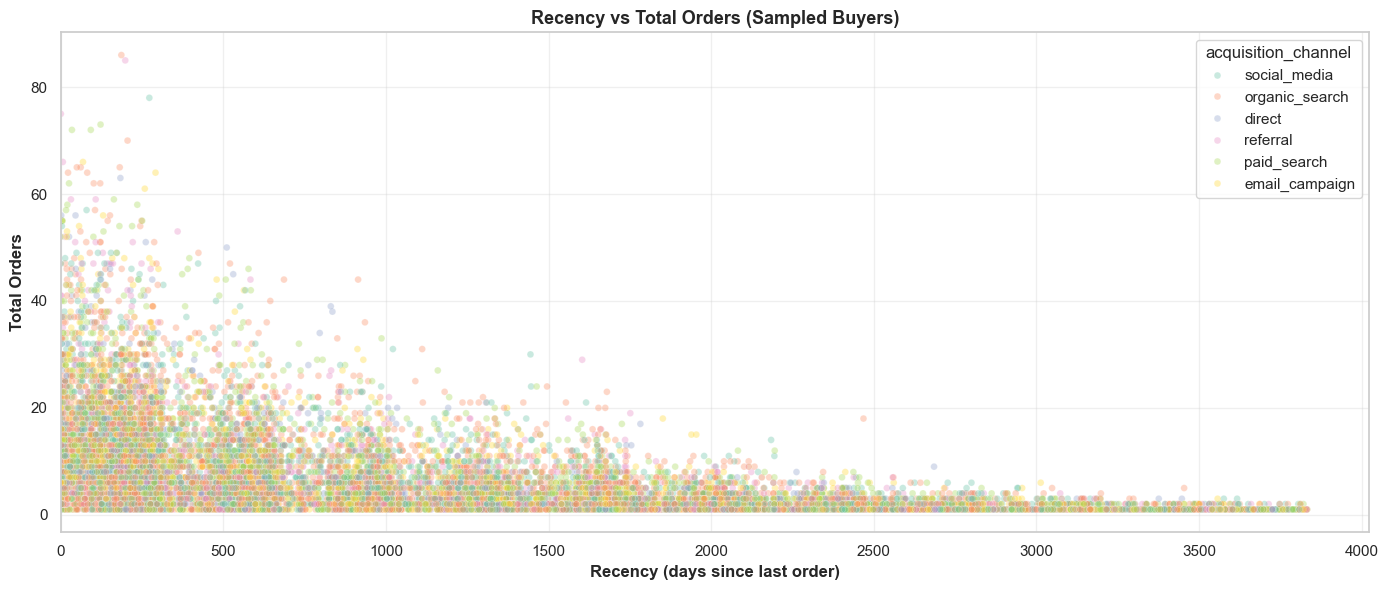

✓ Saved: 04_recency_repeat_scatter.png


In [11]:
# ============================================================================
# CELL 11: VISUALIZATION 4 - Recency vs Repeat
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 6))
sample_buyers = buyers.sample(min(15000, len(buyers)), random_state=SEED)

sns.scatterplot(
    data=sample_buyers,
    x='recency_days',
    y='total_orders',
    hue='acquisition_channel',
    alpha=0.35,
    s=24,
    ax=ax
)
ax.set_title('Recency vs Total Orders (Sampled Buyers)', fontweight='bold', fontsize=13)
ax.set_xlabel('Recency (days since last order)', fontweight='bold')
ax.set_ylabel('Total Orders', fontweight='bold')
ax.set_xlim(left=0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}04_recency_repeat_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved: 04_recency_repeat_scatter.png')

## CELL 12: Export Summary Metrics

In [12]:
# ============================================================================
# CELL 12: EXPORT SUMMARY METRICS
# ============================================================================
top_ch = channel_summary.index[0]
low_ch = channel_summary.index[-1]

summary_data = {
    'Metric': [
        'Total Customers',
        'Total Buyers',
        'Repeat Buyers',
        'Repeat Rate (%)',
        '30D Retention (%)',
        '90D Retention (%)',
        '180D Retention (%)',
        'Best 90D Channel',
        'Best 90D Retention (%)',
        'Worst 90D Channel',
        'Worst 90D Retention (%)',
        'Paid vs Social Retention Ratio (90D)',
        'Forecast Retention Index-3 (%)',
        'Dormant One-Time Buyers (>90d)',
        'Est. Reactivation Revenue Proxy',
    ],
    'Value': [
        f'{len(lifecycle):,}',
        f'{buyers.shape[0]:,}',
        f'{buyers["is_repeat"].sum():,}',
        f'{buyers["is_repeat"].mean()*100:.1f}%',
        f'{buyers["retained_30d"].mean()*100:.1f}%',
        f'{buyers["retained_90d"].mean()*100:.1f}%',
        f'{buyers["retained_180d"].mean()*100:.1f}%',
        top_ch,
        f'{channel_summary.loc[top_ch, "retention_90d"]*100:.1f}%',
        low_ch,
        f'{channel_summary.loc[low_ch, "retention_90d"]*100:.1f}%',
        f'{ratio_paid_social:.2f}x' if pd.notna(ratio_paid_social) else 'N/A',
        f'{forecast_retention_3m*100:.1f}%' if pd.notna(forecast_retention_3m) else 'N/A',
        f'{dormant_90:,}',
        f'${est_reactivation_value:,.0f}',
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(f'{OUTPUT_PATH}summary_metrics.csv', index=False)

print('\n📊 SUMMARY METRICS TABLE')
print('='*70)
print(summary_df.to_string(index=False))
print(f'\n✓ Exported to: {OUTPUT_PATH}summary_metrics.csv')


📊 SUMMARY METRICS TABLE
                              Metric          Value
                     Total Customers        121,930
                        Total Buyers         90,246
                       Repeat Buyers         67,888
                     Repeat Rate (%)          75.2%
                   30D Retention (%)           8.2%
                   90D Retention (%)          17.6%
                  180D Retention (%)          27.4%
                    Best 90D Channel organic_search
              Best 90D Retention (%)          17.8%
                   Worst 90D Channel         direct
             Worst 90D Retention (%)          17.4%
Paid vs Social Retention Ratio (90D)          0.96x
      Forecast Retention Index-3 (%)           0.9%
      Dormant One-Time Buyers (>90d)         22,175
     Est. Reactivation Revenue Proxy    $67,581,476

✓ Exported to: D:\Datathon2026\TuNgayToiGapEm\phan_2_eda\outputs\idea_1\outputs\summary_metrics.csv


## CELL 13: Final Summary & Next Steps

In [13]:
# ============================================================================
# CELL 13: FINAL SUMMARY
# ============================================================================
print('\n' + '='*70)
print('✅ ANALYSIS COMPLETE - IDEA #1 CUSTOMER LIFECYCLE')
print('='*70)

print(f'''\n🎯 ONE-LINER INSIGHT:
"Acquisition tốt không chỉ mua lần 1, mà phải mua lần 2."

📁 OUTPUT FILES GENERATED:
  ✓ 01_cohort_heatmap.png             - Cohort retention matrix
  ✓ 02_channel_retention.png          - Retention by acquisition channel
  ✓ 03_retention_curve.png            - Retention decay curves
  ✓ 04_recency_repeat_scatter.png     - Recency vs repeat behavior
  ✓ summary_metrics.csv               - Key lifecycle metrics

Location: {OUTPUT_PATH}

🔑 KEY FINDINGS:
  - Repeat purchase is the strongest retention signal
  - Acquisition channels differ significantly in 90D retention
  - Dormant one-time buyers are a large reactivation opportunity
  - Retention KPI should be primary, not only CPA/sessions

🚀 READY FOR:
  ✓ EDA report section (D-Di-P-Pr)
  ✓ Marketing budget allocation discussion
  ✓ Re-engagement experiment planning
  ✓ Feature input for forecasting model
''')


✅ ANALYSIS COMPLETE - IDEA #1 CUSTOMER LIFECYCLE

🎯 ONE-LINER INSIGHT:
"Acquisition tốt không chỉ mua lần 1, mà phải mua lần 2."

📁 OUTPUT FILES GENERATED:
  ✓ 01_cohort_heatmap.png             - Cohort retention matrix
  ✓ 02_channel_retention.png          - Retention by acquisition channel
  ✓ 03_retention_curve.png            - Retention decay curves
  ✓ 04_recency_repeat_scatter.png     - Recency vs repeat behavior
  ✓ summary_metrics.csv               - Key lifecycle metrics

Location: D:\Datathon2026\TuNgayToiGapEm\phan_2_eda\outputs\idea_1\outputs\

🔑 KEY FINDINGS:
  - Repeat purchase is the strongest retention signal
  - Acquisition channels differ significantly in 90D retention
  - Dormant one-time buyers are a large reactivation opportunity
  - Retention KPI should be primary, not only CPA/sessions

🚀 READY FOR:
  ✓ EDA report section (D-Di-P-Pr)
  ✓ Marketing budget allocation discussion
  ✓ Re-engagement experiment planning
  ✓ Feature input for forecasting model

